# Escolha de Locais para Centros de Distribuição com K-Means

Uma empresa de logística deseja instalar 3 centros de distribuição em uma região para atender 1000 clientes de forma eficiente. O objetivo é minimizar a distância total de transporte entre os centros e os clientes.

### Coordenadas geográficas (latitude e longitude) dos clientes.

In [ ]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

# Gerar dados fictícios (1000 clientes, 2 clusters naturais)
clientes, _ = make_blobs(n_samples=1000, centers=2, cluster_std=0.8, random_state=0)
df = pd.DataFrame(clientes, columns=['latitude', 'longitude'])

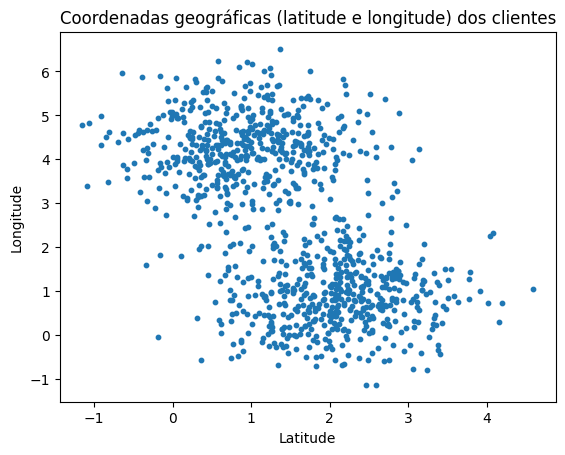

In [ ]:
# Plotar clientes e centroides
plt.scatter(df['latitude'], df['longitude'], s=10)
plt.xlabel('Latitude')
plt.ylabel('Longitude')
plt.title('Coordenadas geográficas (latitude e longitude) dos clientes')
plt.show()

### Aplicação do K-Means

O algoritmo agrupará os clientes em 3 clusters e calculará o centroide (ponto médio) de cada cluster, que será a localização ideal do centro de distribuição.

In [ ]:
from sklearn.cluster import KMeans

# Definir o número de clusters (k = 3)
kmeans = KMeans(n_clusters=3, random_state=42)

kmeans.fit(df)

# Obter coordenadas dos centroides
centroides = kmeans.cluster_centers_
print("Melhores locais para os centros (centroides):\n", centroides)

Melhores locais para os centros (centroides):
 [[1.67838301 1.88408229]
 [0.87875788 4.38474332]
 [2.2413255  0.50992919]]


### Visualização dos Resultados

A rotulagem de uma nova amostra é realizada encontrando o centróide mais próximo para uma determinada amostra.

Os centroides representam as coordenadas médias dos clientes de cada cluster, minimizando a distância total.

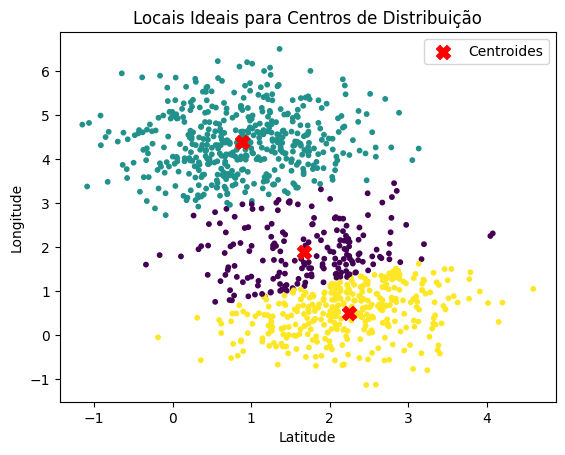

In [ ]:
# Plotar clientes e centroides
plt.scatter(df['latitude'], df['longitude'], c=kmeans.labels_, cmap='viridis', s=10)
plt.scatter(centroides[:,0], centroides[:,1], c='red', marker='X', s=100, label='Centroides')
plt.xlabel('Latitude')
plt.ylabel('Longitude')
plt.title('Locais Ideais para Centros de Distribuição')
plt.legend()
plt.show()

Será que 3 centros de distribuição é a quantidade correta para minimizar a distância entre os clientes e os centros?

Se necessário, podemos encontrar o número de clusters (k) ideal usando métodos como o Elbow Method ou Silhouette Score.

### Método do Cotovelo (Elbow Method) para escolher o número ideal de clusters ($k$)

Essa abordagem utiliza a Soma dos Quadrados Intra-Clusters (WSS - Within-Cluster Sum of Squares) e analisa a curva de WSS em função de
$k$.

A curva quantifica o quão próximos os pontos de um cluster estão do seu centróide (centro do cluster). Quanto menor o WSS, mais coesos são os clusters.

A equação do **Within-Cluster Sum of Squares (WSS)** é:
$$WSS = \sum_{i=1}^{k} \sum_{x \in C_i} \|x - \mu_i\|^2$$,
onde:
- $k$ -> número de clusters,
- $C_i$ -> conjunto de pontos no cluster \( i \),
- $mu_i$ = centróide (média) do cluster \( i \),
- $ \|x - \mu_i\|^2 $ -> distância quadrada (Euclidiana) entre um ponto $x$ e seu centróide.


O objetivo é encontrar um $k$ onde aumentar o número de clusters não reduz significativamente o WSS. Isso ocorre a partir do cotovelo da curva.

Assim, o valor ideal de $k$ é encontrando localizando-se o cotovelo na curva.

Quando o cotovelo na curva não é claramente visível, uma técnica comum é traçar uma reta conectando os pontos extremos da curva e identificar o ponto mais distante dessa reta como o "cotovelo" ideal.

### Calcular WSS para k de 1 a 10

In [ ]:
wss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df)
    wss.append(kmeans.inertia_)

### Plotar a Curva de WSS e a Reta entre Extremos

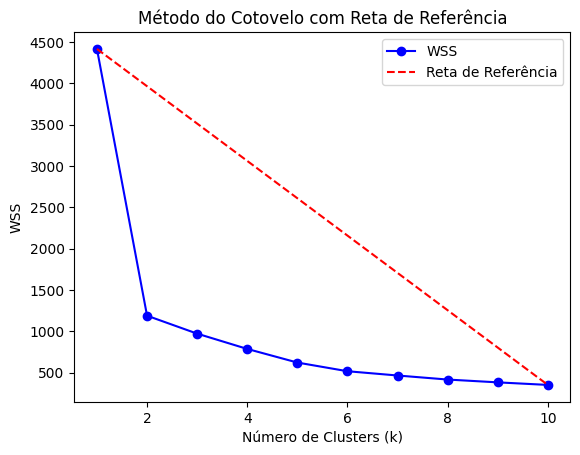

In [ ]:
k_values = range(1, 11)
plt.plot(k_values, wss, 'bo-', label='WSS')

# Definir extremos (primeiro e último pontos)
primeiro_ponto = (1, wss[0])
ultimo_ponto = (10, wss[-1])

# Equação da reta entre os extremos (y = a*x + b)
x = np.array([1, 10])
y = np.array([wss[0], wss[-1]])
a, b = np.polyfit(x, y, 1)

# Plotar a reta
plt.plot(x, a*x + b, 'r--', label='Reta de Referência')

plt.xlabel('Número de Clusters (k)')
plt.ylabel('WSS')
plt.title('Método do Cotovelo com Reta de Referência')
plt.legend()
plt.show()

###  Identificar o Ponto Mais Distante da Reta

In [ ]:
# Calcular distâncias dos pontos à reta
distancias = []
for k in range(1, 11):
    y_reta = a * k + b
    distancia = abs(wss[k-1] - y_reta)
    distancias.append(distancia)

# Encontrar o k com maior distância
k_otimo = np.argmax(distancias) + 1  # +1 pois o índice começa em 0
print(f"Número ideal de clusters: k = {k_otimo}")

Número ideal de clusters: k = 2
